<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/lab4_pe_led.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect. LED measurements


0.1.0

0.2.0 Seven new diodes with measured spectrum

0.2.1 Observed band instead of nominal

# Resume



# LED equation

$$
 h \frac{c}{\lambda} = e V_0
$$

In [43]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request

In [44]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

# Measurements by optical spectroscope

First order $n=1$
$$ \lambda = d \sin\theta$$

In [45]:
d = 1e-3 / 500 # 500 lines per mm
data = '''
# band_nominal(from..to)[nm] thetas1(from..to)[deg] thetas2(from .. to)[deg]
500 510 13.88 16.01 13.71 16.39
390 395 11.38 12.41 11.40 12.57 # and weak green-red band 14.2 18.6
730 730 19.2 21.56 18.56 21.9
540 550 14.76 17.75 14.92 17.44
560 570 15.25 18.50 15.46 18.07
520 525 14.20 17.60 14.50 17.40
420 425 11.5 12.6 11.6 12.70
405 410 11.45 12.51 11.44 12.40
'''
wl_nominal1, wl_nominal2, thetaleft1, thetaright1, thetaleft2, thetaright2 = np.genfromtxt(data.splitlines()).T
thetaleft = (thetaleft1 + thetaleft2) / 2
thetaright = (thetaright1 + thetaright2) / 2
bleft = d * np.sin(np.deg2rad(thetaleft))*1e9
bright = d * np.sin(np.deg2rad(thetaright))*1e9
wl_observed = (bleft + bright) / 2
wl_observed_err = (bright - bleft) / 2
for i in range(len(bleft)):
  print(f'{wl_nominal1[i]:.0f}-{wl_nominal2[i]:.0f}nm: {wl_observed[i]:.0f} +- {wl_observed_err[i]:.0f} nm')

def get_observed_by_nominal(wl_nominal):
  d = 1e-3 / 500 # 500 lines per mm
  data = '''
  # band_nominal(from..to)[nm] thetas1(from..to)[deg] thetas2(from .. to)[deg]
  500 510 13.88 16.01 13.71 16.39
  390 395 11.38 12.41 11.40 12.57 # and weak green-red band 14.2 18.6
  730 730 19.2 21.56 18.56 21.9
  540 550 14.76 17.75 14.92 17.44
  560 570 15.25 18.50 15.46 18.07
  520 525 14.20 17.60 14.50 17.40
  420 425 11.5 12.6 11.6 12.70
  405 410 11.45 12.51 11.44 12.40
  '''
  if wl_nominal ==730:
    return 730, 10
  wl_nominal1, wl_nominal2, thetaleft1, thetaright1, thetaleft2, thetaright2 = np.genfromtxt(data.splitlines()).T
  thetaleft = (thetaleft1 + thetaleft2) / 2
  thetaright = (thetaright1 + thetaright2) / 2
  bleft = d * np.sin(np.deg2rad(thetaleft))*1e9
  bright = d * np.sin(np.deg2rad(thetaright))*1e9
  wl_observed = (bleft + bright) / 2
  wl_observed_err = (bright - bleft) / 2 / np.sqrt(3)
  mask = (wl_nominal1 <= wl_nominal) & (wl_nominal <= wl_nominal2)
  return wl_observed[mask][0], wl_observed_err[mask][0]

get_observed_by_nominal(420)

500-510nm: 517 +- 41 nm
390-395nm: 414 +- 19 nm
730-730nm: 694 +- 47 nm
540-550nm: 558 +- 46 nm
560-570nm: 579 +- 49 nm
520-525nm: 549 +- 53 nm
420-425nm: 419 +- 19 nm
405-410nm: 414 +- 17 nm


(np.float64(419.21781028257044), np.float64(10.837905076947125))

#Volt-ampere curve


In [46]:
def find_root(V, I, tolerance=0.99):
  ans = np.nan
  left_edges = np.linspace(np.min(V), np.max(V), 50)
  for left in left_edges:
    mask = (V > left)
    fit = linregress(V[mask], I[mask])
    r2 = fit.rvalue**2
    if r2 > tolerance:
      break
  V0 = - fit.intercept / fit.slope
  return V0

#wl V0
395 2.76 414 11
405 2.73 414 10
420 2.70 419 11
500 2.19 517 23
520 2.08 549 31
540 2.01 558 27
560 1.84 579 28
730 1.39 730 10



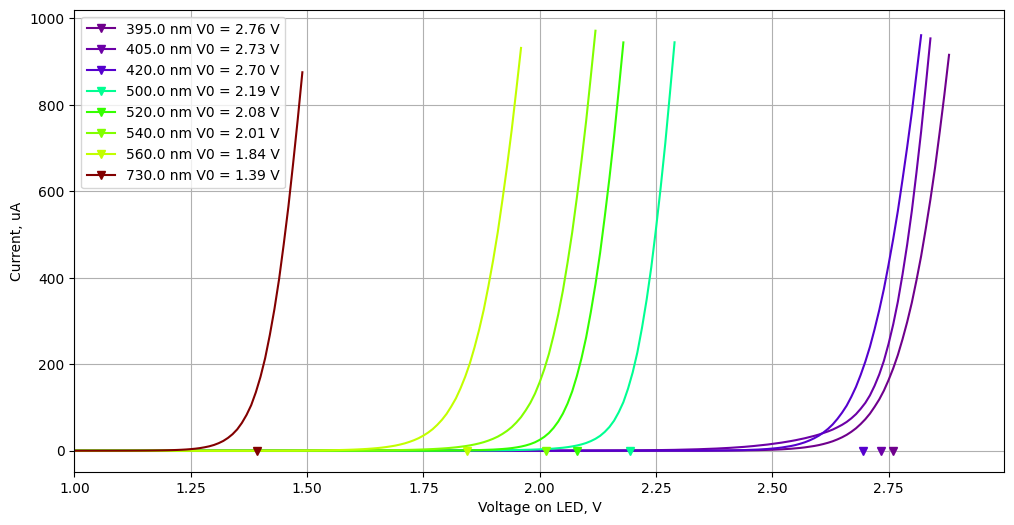

In [47]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/LED/'
MAX_CURRENT = 0.99e-3 #A

name = 'LED_VAC_7diodes'
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)
fig, ax = plt.subplots(figsize=(12,6))
data = '#wl V0\n'
for wl in np.unique(WL):
  mask = (WL == wl) & (I < MAX_CURRENT )
  color = wavelength_to_color(wl)
  plt.plot(V[mask], I[mask]*1e6, color=color)
  V0 = find_root(V[mask], I[mask])
  plt.plot(V0, 0, color=color, marker='v', label=f'{wl} nm V0 = {V0:.2f} V')
  freq = c/wl *1e9
  wl_observed = get_observed_by_nominal(wl)[0]
  wl_observed_err = get_observed_by_nominal(wl)[1]
  data += f'{wl:.0f} {V0:.2f} {wl_observed:.0f} {wl_observed_err:.0f}\n'
  #data += f'{wl:.0f} {V0:.2f}

plt.legend()
plt.xlabel('Voltage on LED, V')
plt.ylabel('Current, uA')
plt.xlim(left=1)
plt.grid()

print(data)




# Planck

/tmp/ipykernel_11702/2793832377.py:6: RuntimeWarning: divide by zero encountered in divide
  return c * h/ e / energy  * 1e9


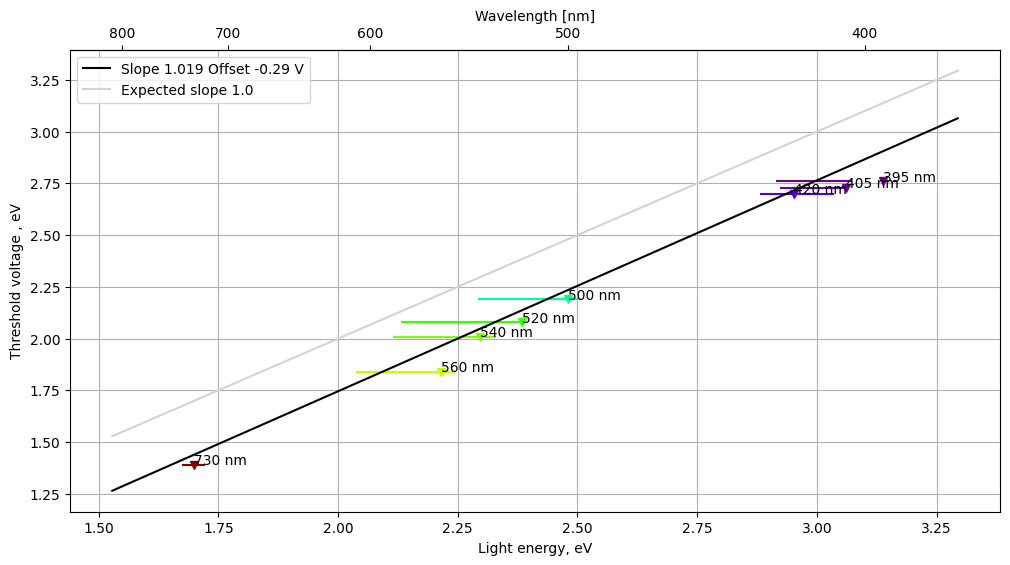

In [48]:
def wl2E(wl):
    return c * h / e / (wl *1e-9)


def E2wl(energy):
    return c * h/ e / energy  * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(wl2E, E2wl))
secax.set_xlabel('Wavelength [nm]')


wl_nominal, V0, wl_observed, wl_observed_err = np.genfromtxt(data.splitlines()).T



relative_error = wl_observed_err / wl_observed #

wl_observed *= 1e-9
nu = c / wl_observed
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
fit = linregress(energy, V0)
slope = fit.slope
offset = fit.intercept




for i in range(len(V0)):
  plt.errorbar( energy[i], V0[i], yerr=0, xerr=energy_err[i], ls='', color=wavelength_to_color(wl_nominal[i]))
  plt.plot( wl2E(wl_nominal[i]), V0[i], marker='v', color=wavelength_to_color(wl_nominal[i]))
  plt.annotate(f'{wl_nominal[i]:.0f} nm', (wl2E(wl_nominal[i]), V0[i]))

en_dense = np.linspace(np.min(energy)*0.9, np.max(energy)*1.1)

plt.plot(en_dense, en_dense * slope + offset, color='black',\
         label=rf'Slope {slope:.3f} Offset {offset:.2f} V')
plt.plot(en_dense, en_dense , color='lightgray', label=f'Expected slope 1.0')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light energy, eV')
plt.ylabel(r'Threshold voltage , eV')
plt.legend()
plt.show()